# 05a — XGBoost Global Model (Weekly)
## One Model for All 122 Items — Cross-Item Learning with Engineered Features

**Purpose.** Train a single XGBoost regressor on all 122 items simultaneously
using the weekly feature matrix from notebook 03. This is the first model that
can learn cross-item patterns — Cappuccino's weekly rhythm informs Matcha
Latte's forecast through the hierarchical (section / total) features.

**Input:** `weekly_features.csv` (engineered features × ~17,000 rows from notebook 03)

**Outputs:**
- `xgboost_weekly_predictions.csv` — predictions on val + test sets
- `xgboost_weekly_metrics.csv` — per-item metrics
- `xgboost_weekly_summary.json` — overall summary
- `xgboost_weekly_feature_importance.csv` — feature importance for SHAP analysis
- `models/xgboost_weekly/model.json` — single global model (FastAPI-ready)
- `models/xgboost_weekly/manifest.json` — feature order + encoding maps

**Why XGBoost on weekly:**
- Handles the rich weekly feature set (lags, rolling stats, hierarchical context, holiday × category interactions)
- Native support for missing values, mixed feature types
- Built-in early stopping prevents overfitting on the smaller weekly dataset
- Tree-based: robust to feature scaling, captures non-linearities (Ramadan × section interactions)
- SHAP-compatible for XAI (PRD requirement)
- Fast inference (~ms per prediction) — production-ready for FastAPI

**Hypothesis from notebook 04c:** With explicit Ramadan × section and holiday × category interactions
combined with hierarchical lag features, XGBoost should beat both Prophet and SARIMA on the weekly
horizon, particularly on low-volume items where per-item methods structurally fail.

---


## 1. Setup


In [1]:
!pip install xgboost --quiet



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATASETS_DIR = '../../datasets'
MODELS_DIR = '../../models/xgboost'
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"XGBoost version: {xgb.__version__}")
print(f"Working directory: {os.getcwd()}")
print(f"Models will be saved to: {os.path.abspath(MODELS_DIR)}")


XGBoost version: 3.2.0
Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\XGboost
Models will be saved to: c:\Users\slimc\Desktop\Notebooks\models\xgboost


## 2. Load weekly feature matrix


In [3]:
# Load the weekly feature matrix from notebook 03
# (Filenames match what notebook 03 actually saves)
df = pd.read_csv(os.path.join(DATASETS_DIR, 'forecasting_features_weekly.csv'),
                 parse_dates=['week_start'])

# Auxiliary files produced by notebook 03
try:
    with open(os.path.join(DATASETS_DIR, 'feature_lists_weekly.json')) as f:
        feature_config = json.load(f)
    feature_cols = feature_config['tree_features']
    target_col = feature_config['target']
except FileNotFoundError:
    # Fallback: derive feature list automatically.
    # META matches notebook 03's meta_cols definition exactly.
    META = {'week_start', 'item_name', 'item_id', 'section', 'category',
            'holiday_type', 'split', 'quantity'}
    feature_cols = [c for c in df.columns
                    if c not in META
                    and df[c].dtype in ['int64', 'float64', 'int32', 'float32']]
    target_col = 'quantity'
    print("(feature_lists_weekly.json not found — derived features automatically)")

# Encoding maps (for FastAPI inference reconstruction)
try:
    with open(os.path.join(DATASETS_DIR, 'encoding_maps_weekly.json')) as f:
        encoding_maps = json.load(f)
except FileNotFoundError:
    encoding_maps = {}

print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Tree features: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())
print(f"\nDate ranges:")
for split in ['train', 'val', 'test']:
    sub = df[df['split'] == split]
    if len(sub) > 0:
        print(f"  {split:5s}: {sub['week_start'].min().date()} → {sub['week_start'].max().date()}  ({len(sub):,} rows, {sub['week_start'].nunique()} weeks)")


Loaded: 18,056 rows × 93 columns
Tree features: 85
Target: quantity

Split distribution:
train    11712
test      4758
val       1586
Name: split, dtype: int64

Date ranges:
  train: 2023-02-28 → 2024-12-24  (11,712 rows, 96 weeks)
  val  : 2024-12-31 → 2025-03-25  (1,586 rows, 13 weeks)
  test : 2025-04-01 → 2025-12-23  (4,758 rows, 39 weeks)


## 3. Prepare train / validation / test sets


In [4]:
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

# Remove leaky / unhelpful identifiers that would let the model memorize
features_to_remove = ['item_encoded', 'weeks_since_start']
features_to_remove = [f for f in features_to_remove if f in feature_cols]
feature_cols = [c for c in feature_cols if c not in features_to_remove]
if features_to_remove:
    print(f"Features removed (would leak identity / induce trend memorization): {features_to_remove}")
print(f"Remaining features: {len(feature_cols)}")

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

# Identifiers for prediction merging
train_ids = train_df[['week_start', 'item_name']].reset_index(drop=True)
val_ids = val_df[['week_start', 'item_name', 'section', 'category']].reset_index(drop=True)
test_ids = test_df[['week_start', 'item_name', 'section', 'category']].reset_index(drop=True)

print(f"\nTrain: {X_train.shape}  →  y range [{y_train.min():.0f}, {y_train.max():.0f}]  mean={y_train.mean():.2f}")
print(f"Val:   {X_val.shape}    →  y range [{y_val.min():.0f}, {y_val.max():.0f}]  mean={y_val.mean():.2f}")
print(f"Test:  {X_test.shape}   →  y range [{y_test.min():.0f}, {y_test.max():.0f}]  mean={y_test.mean():.2f}")

# DMatrix is XGBoost's optimized data structure
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_cols)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=feature_cols)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)
print("\n✓ DMatrix conversion complete")


Features removed (would leak identity / induce trend memorization): ['weeks_since_start']
Remaining features: 84

Train: (11712, 84)  →  y range [0, 43]  mean=9.13
Val:   (1586, 84)    →  y range [0, 37]  mean=7.73
Test:  (4758, 84)   →  y range [0, 39]  mean=10.22

✓ DMatrix conversion complete


## 4. Metric functions (same suite as 04a/04b for direct comparison)


In [5]:
def compute_metrics(actual, predicted, train_actual=None):
    """WAPE, MAE, RMSE, R², MAPE, sMAPE, MASE, Bias."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors**2).mean())
    bias = errors.mean()

    nonzero = actual > 0
    mape = (abs_errors[nonzero] / actual[nonzero]).mean() if nonzero.sum() > 0 else np.nan

    denom = (np.abs(actual) + np.abs(predicted)) / 2
    smape_mask = denom > 0
    smape = (abs_errors[smape_mask] / denom[smape_mask]).mean() if smape_mask.sum() > 0 else np.nan

    actual_sum = actual.sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf

    ss_res = (errors**2).sum()
    ss_tot = ((actual - actual.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    # MASE — uses seasonal naive (lag-52 for weekly) when enough history exists
    mase = np.nan
    if train_actual is not None and len(train_actual) > 52:
        naive_errors = np.abs(train_actual[52:] - train_actual[:-52])
        mae_naive = naive_errors.mean()
        if mae_naive > 0:
            mase = mae / mae_naive

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape,
            'wape': wape, 'mase': mase, 'r2': r2, 'bias': bias}

print("Metric function ready: MAE, RMSE, MAPE, sMAPE, WAPE, MASE, R², Bias")


Metric function ready: MAE, RMSE, MAPE, sMAPE, WAPE, MASE, R², Bias


## 5. Train XGBoost with live loss tracking

**Hyperparameters chosen for weekly data** (smaller dataset than daily):
- `count:poisson` objective — quantity is non-negative count data
- `max_depth=6` — shallower than daily because weekly has ~10x fewer rows
- `learning_rate=0.05` + `early_stopping_rounds=50` — let early stopping find the right number of trees
- `min_child_weight=3` — guards against overfitting on rare items
- `reg_lambda=1.0` — L2 regularization


In [6]:
params = {
    'objective': 'count:poisson',
    'eval_metric': ['mae', 'rmse'],
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'min_child_weight': 3,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'tree_method': 'hist',
    'seed': 42,
}

evals_result = {}
print("=" * 60)
print("XGBOOST TRAINING — LIVE BOOSTING ROUNDS (weekly)")
print("=" * 60)
print()

start_time = time.time()
model = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=50,
    evals_result=evals_result,
)
training_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"✓ Training complete: {training_time:.1f}s")
print(f"✓ Best iteration:    {model.best_iteration}")
print(f"✓ Best val MAE:      {model.best_score:.4f}")
print(f"✓ Total trees built: {model.num_boosted_rounds()}")
print(f"{'='*60}")


XGBOOST TRAINING — LIVE BOOSTING ROUNDS (weekly)

[0]	train-mae:4.30043	train-rmse:5.52453	val-mae:4.31547	val-rmse:5.34183
[50]	train-mae:2.66158	train-rmse:3.40769	val-mae:2.68892	val-rmse:3.38315
[100]	train-mae:2.36570	train-rmse:3.03779	val-mae:2.43180	val-rmse:3.10874
[150]	train-mae:2.26416	train-rmse:2.90714	val-mae:2.38849	val-rmse:3.07087
[200]	train-mae:2.19122	train-rmse:2.81266	val-mae:2.37410	val-rmse:3.06552
[228]	train-mae:2.15450	train-rmse:2.76167	val-mae:2.37216	val-rmse:3.06760

✓ Training complete: 0.6s
✓ Best iteration:    178
✓ Best val MAE:      3.0643
✓ Total trees built: 229


## 6. Learning curves — train vs validation loss


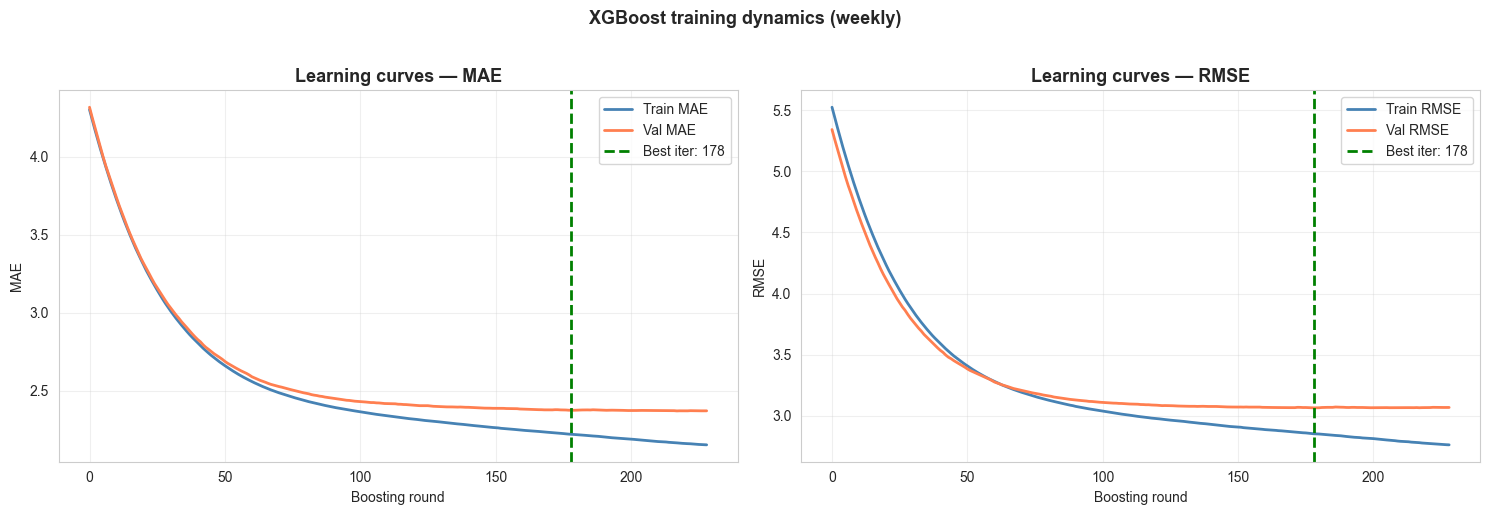


Train-val MAE gap at best iteration: 0.1540
  Train MAE: 2.2217
  Val MAE:   2.3756
  → Small gap, healthy fit


In [7]:
train_mae = evals_result['train']['mae']
val_mae = evals_result['val']['mae']
train_rmse = evals_result['train']['rmse']
val_rmse = evals_result['val']['rmse']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE
ax = axes[0]
ax.plot(train_mae, label='Train MAE', color='steelblue', linewidth=2)
ax.plot(val_mae, label='Val MAE', color='coral', linewidth=2)
ax.axvline(model.best_iteration, color='green', linestyle='--', linewidth=2,
           label=f'Best iter: {model.best_iteration}')
ax.set_xlabel('Boosting round')
ax.set_ylabel('MAE')
ax.set_title('Learning curves — MAE')
ax.legend()
ax.grid(alpha=0.3)

# RMSE
ax = axes[1]
ax.plot(train_rmse, label='Train RMSE', color='steelblue', linewidth=2)
ax.plot(val_rmse, label='Val RMSE', color='coral', linewidth=2)
ax.axvline(model.best_iteration, color='green', linestyle='--', linewidth=2,
           label=f'Best iter: {model.best_iteration}')
ax.set_xlabel('Boosting round')
ax.set_ylabel('RMSE')
ax.set_title('Learning curves — RMSE')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('XGBoost training dynamics (weekly)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('xgboost_weekly_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnostic: gap between train and val (sign of overfitting)
final_gap = val_mae[model.best_iteration] - train_mae[model.best_iteration]
print(f"\nTrain-val MAE gap at best iteration: {final_gap:.4f}")
print(f"  Train MAE: {train_mae[model.best_iteration]:.4f}")
print(f"  Val MAE:   {val_mae[model.best_iteration]:.4f}")
if final_gap < 0.5:
    print(f"  → Small gap, healthy fit")
elif final_gap < 1.5:
    print(f"  → Moderate gap, mild overfitting (normal for tree models on weekly)")
else:
    print(f"  → Large gap, consider stronger regularization")


## 7. Generate predictions on val + test


In [8]:
# Predict at best iteration (early stopping point)
val_preds = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
test_preds = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))

# Demand can't be negative
val_preds = np.clip(val_preds, 0, None)
test_preds = np.clip(test_preds, 0, None)

# Standard format (matches Prophet/SARIMA output)
val_pred_df = val_ids.copy()
val_pred_df['actual'] = y_val
val_pred_df['predicted'] = val_preds
val_pred_df['split'] = 'val'

test_pred_df = test_ids.copy()
test_pred_df['actual'] = y_test
test_pred_df['predicted'] = test_preds
test_pred_df['split'] = 'test'

predictions_df = pd.concat([val_pred_df, test_pred_df], ignore_index=True)
predictions_df = predictions_df.rename(columns={'week_start': 'ds'})

print(f"Predictions generated:")
print(f"  Val:  {len(val_pred_df):,} rows")
print(f"  Test: {len(test_pred_df):,} rows")
print(f"  Total: {len(predictions_df):,} rows")


Predictions generated:
  Val:  1,586 rows
  Test: 4,758 rows
  Total: 6,344 rows


## 8. Compute naive baselines (for the comparison table)


In [9]:
# Use the same baselines as 04a/04b for consistency
df_orig = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                      parse_dates=['week_start'])

TRAIN_END_W = pd.Timestamp('2024-12-30')
VAL_END_W = pd.Timestamp('2025-03-31')
df_orig['split'] = 'train'
df_orig.loc[df_orig['week_start'] > TRAIN_END_W, 'split'] = 'val'
df_orig.loc[df_orig['week_start'] > VAL_END_W, 'split'] = 'test'

items = sorted(df_orig['item_name'].unique())
forecast_dates = sorted(df_orig[df_orig['split'].isin(['val', 'test'])]['week_start'].unique())
n_forecast = len(forecast_dates)

naive_results = {'seasonal_naive': [], 'mean': [], 'last_value': []}

for item in items:
    item_train = df_orig[(df_orig['item_name'] == item) & (df_orig['split'] == 'train')].sort_values('week_start')
    item_actual = df_orig[(df_orig['item_name'] == item) & (df_orig['split'].isin(['val', 'test']))].sort_values('week_start')

    train_qty = item_train['quantity'].values
    actual_qty = item_actual['quantity'].values

    if len(train_qty) == 0 or len(actual_qty) == 0:
        continue

    # Seasonal naive at weekly = lag-52 (yearly seasonality)
    if len(train_qty) >= 52:
        last_year = train_qty[-52:]
        seasonal_pred = np.tile(last_year, n_forecast // 52 + 1)[:n_forecast]
    else:
        # Fallback: use last value
        seasonal_pred = np.full(n_forecast, train_qty[-1])
    mean_pred = np.full(n_forecast, train_qty.mean())
    last_pred = np.full(n_forecast, train_qty[-1])

    for name, pred in [('seasonal_naive', seasonal_pred), ('mean', mean_pred), ('last_value', last_pred)]:
        for split in ['val', 'test']:
            split_mask = item_actual['split'].values == split
            if split_mask.sum() > 0:
                actual_split = actual_qty[split_mask]
                # Pred is indexed by position in the val+test sequence
                pred_idxs = np.where(item_actual['split'].values != 'train')[0]
                pred_subset_idxs = np.where(item_actual['split'].values == split)[0]
                # Simple alignment: pred is in same order as actual_qty
                actual_order = item_actual.reset_index(drop=True)
                pred_aligned = pred[:len(actual_qty)]
                m = compute_metrics(actual_split, pred_aligned[split_mask], train_qty)
                m['item_name'] = item
                m['split'] = split
                naive_results[name].append(m)

naive_dfs = {k: pd.DataFrame(v) for k, v in naive_results.items()}
print("Naive baselines computed (seasonal_naive uses lag-52 for weekly yearly seasonality)")


Naive baselines computed (seasonal_naive uses lag-52 for weekly yearly seasonality)


## 9. Overall metrics — XGBoost vs naive baselines


XGBOOST OVERALL — vs naive baselines (weekly)
         Model Split    MAE   RMSE   WAPE  sMAPE      R²    Bias
seasonal_naive   val 3.2163 4.0140 0.4684 0.4949 -0.9064 -0.0095
seasonal_naive  test 3.5557 4.4877 0.3882 0.4185 -0.8228  0.4985
          mean   val 3.1434 3.7372 0.4724 0.4529 -0.6884 -1.2703
          mean  test 2.8912 3.7003 0.3087 0.3256 -0.1592  1.2239
    last_value   val 4.3134 4.9618 0.6270 0.5557 -2.4877 -2.4912
    last_value  test 4.1564 4.9449 0.4593 0.4770 -1.4437  0.0029
       xgboost   val 2.3756 3.0643 0.3073 0.3740  0.6579 -0.4843
       xgboost  test 2.6723 3.4845 0.2614 0.3063  0.6707  0.2637


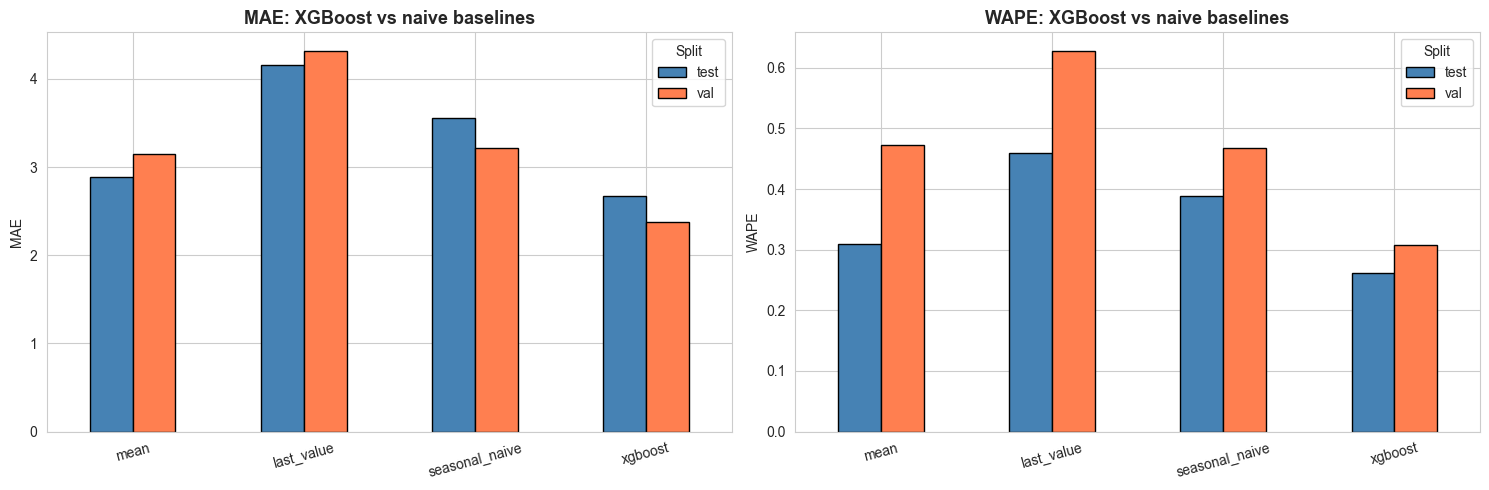

In [10]:
comparison_rows = []

for name, df_n in naive_dfs.items():
    for split in ['val', 'test']:
        sub = df_n[df_n['split'] == split]
        comparison_rows.append({
            'Model': name, 'Split': split,
            'MAE': sub['mae'].mean(), 'RMSE': sub['rmse'].mean(),
            'WAPE': sub['wape'].mean(), 'sMAPE': sub['smape'].mean(),
            'R²': sub['r2'].mean(), 'Bias': sub['bias'].mean(),
        })

# XGBoost (aggregate)
for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    agg = compute_metrics(sp['actual'].values, sp['predicted'].values)
    comparison_rows.append({
        'Model': 'xgboost', 'Split': split,
        'MAE': agg['mae'], 'RMSE': agg['rmse'], 'WAPE': agg['wape'],
        'sMAPE': agg['smape'], 'R²': agg['r2'], 'Bias': agg['bias'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 80)
print("XGBOOST OVERALL — vs naive baselines (weekly)")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format='%.4f'))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'WAPE']):
    pivot = comparison_df.pivot(index='Model', columns='Split', values=metric)
    pivot = pivot.reindex(['mean', 'last_value', 'seasonal_naive', 'xgboost'])
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric}: XGBoost vs naive baselines')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('xgboost_weekly_vs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Per-item metrics


In [11]:
per_item_metrics = []

train_data_dict = {}
for item in items:
    train_data_dict[item] = df_orig[
        (df_orig['item_name'] == item) & (df_orig['split'] == 'train')
    ]['quantity'].values

for split in ['val', 'test']:
    split_pred = predictions_df[predictions_df['split'] == split]
    for item in items:
        item_pred = split_pred[split_pred['item_name'] == item]
        if len(item_pred) > 0:
            m = compute_metrics(
                item_pred['actual'].values,
                item_pred['predicted'].values,
                train_data_dict[item]
            )
            m['item_name'] = item
            m['split'] = split
            m['n_predictions'] = len(item_pred)
            per_item_metrics.append(m)

metrics_df = pd.DataFrame(per_item_metrics)
print(f"Per-item metrics computed: {len(metrics_df)} rows ({metrics_df['item_name'].nunique()} items × {metrics_df['split'].nunique()} splits)")


Per-item metrics computed: 244 rows (122 items × 2 splits)


## 11. Per-section evaluation


XGBOOST — Per-section metrics (weekly)
      section split  n_items    mae   rmse   wape  smape      r2    bias
     American  test       21 3.0091 3.7748 0.2655 0.2805 -0.0391  0.4569
     American   val       21 3.0606 3.7546 0.3464 0.3618 -0.0375 -0.2516
         Cafe  test       17 3.1176 3.9598 0.2356 0.2437  0.1245  0.6071
         Cafe   val       17 2.2682 2.7565 0.2625 0.3029  0.4904 -0.1619
Healthy_Vegan  test       12 2.4715 3.0989 0.3243 0.3464 -0.0470  0.2990
Healthy_Vegan   val       12 1.7979 2.2659 0.3690 0.4065  0.0490 -0.8771
      Italian  test       22 2.5762 3.2606 0.2941 0.3087  0.0495  0.0994
      Italian   val       22 2.2817 2.7439 0.3955 0.3926 -0.0198 -0.6987
     Japanese  test       16 2.6596 3.3143 0.3012 0.3154 -0.0585  0.1440
     Japanese   val       16 2.3910 2.8606 0.3969 0.3898 -0.2922 -0.9486
      Mexican  test       19 2.5669 3.2193 0.3058 0.3174 -0.0224  0.1419
      Mexican   val       19 2.3679 2.9137 0.3429 0.3560  0.0223 -0.3559
   Steakhous

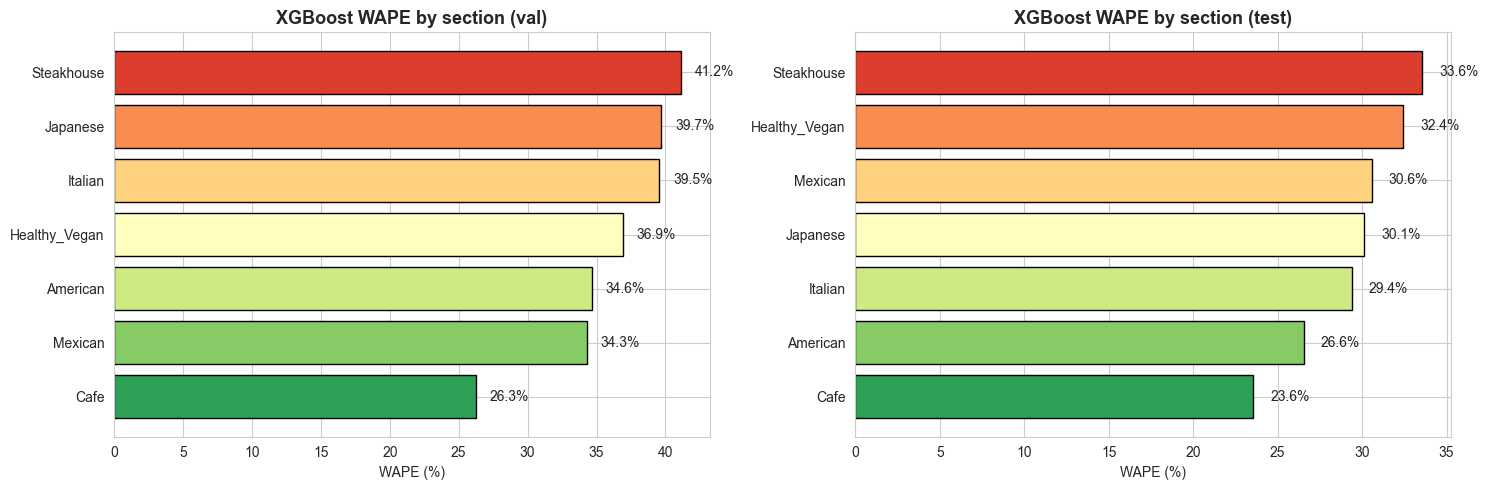

In [12]:
section_map = df_orig[['item_name', 'section', 'category']].drop_duplicates().reset_index(drop=True)
metrics_with_section = metrics_df.merge(section_map, on='item_name')

section_results = metrics_with_section.groupby(['section', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'),
    rmse=('rmse', 'mean'),
    wape=('wape', 'mean'),
    smape=('smape', 'mean'),
    r2=('r2', 'mean'),
    bias=('bias', 'mean'),
).reset_index()

print("=" * 70)
print("XGBOOST — Per-section metrics (weekly)")
print("=" * 70)
print(section_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, split in zip(axes, ['val', 'test']):
    sec_data = section_results[section_results['split'] == split].sort_values('wape')
    bars = ax.barh(sec_data['section'], sec_data['wape']*100,
                   color=sns.color_palette('RdYlGn_r', len(sec_data)),
                   edgecolor='black')
    ax.set_title(f'XGBoost WAPE by section ({split})')
    ax.set_xlabel('WAPE (%)')
    for bar, val in zip(bars, sec_data['wape']*100):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('xgboost_weekly_per_section.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Per-volume-tier evaluation


XGBOOST — Performance by volume tier (weekly)
     volume_tier split  n_items    mae   wape  smape      r2
     Low (<7/wk)  test       46 2.0128 0.3600 0.3837 -0.0101
     Low (<7/wk)   val       46 1.8491 0.4556 0.4699 -0.1077
Medium (7-35/wk)  test       76 3.0715 0.2506 0.2595  0.0225
Medium (7-35/wk)   val       76 2.6943 0.3019 0.3159  0.0778


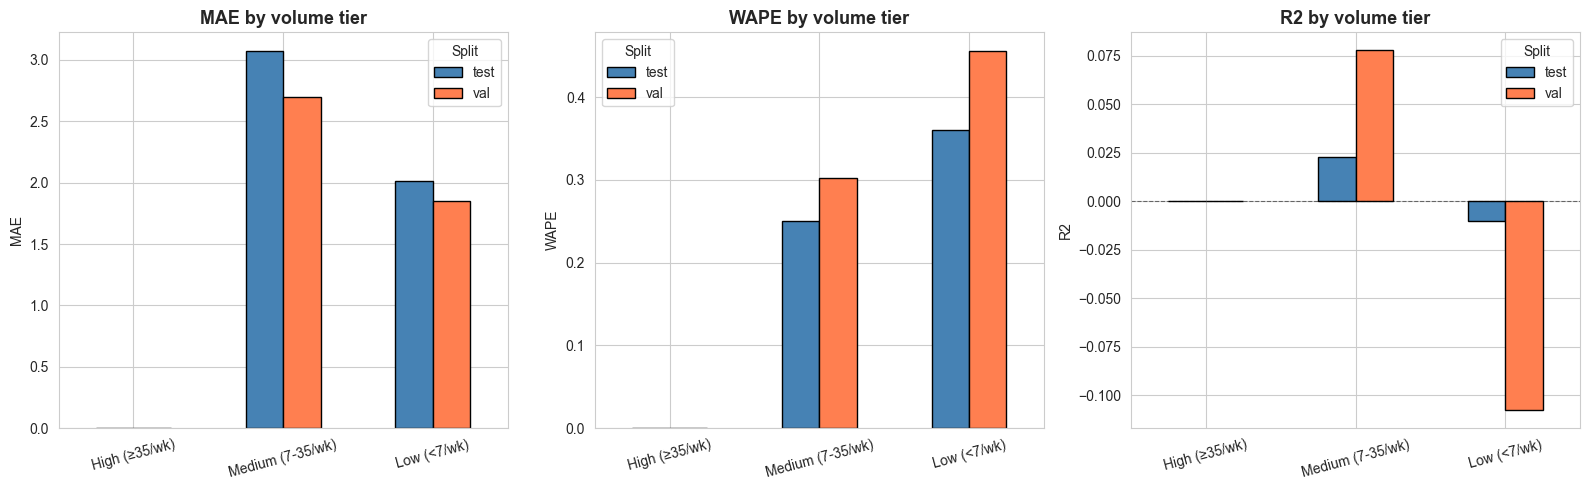

In [13]:
item_volume = df_orig[df_orig['split']=='train'].groupby('item_name')['quantity'].mean().sort_values(ascending=False)

# Weekly thresholds (about 7x the daily ones since we're aggregating 7 days)
def assign_tier(avg):
    if avg >= 35: return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else: return 'Low (<7/wk)'

item_tiers = item_volume.apply(assign_tier).rename('volume_tier').reset_index()
metrics_with_tier = metrics_df.merge(item_tiers, on='item_name')

tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
tier_results = metrics_with_tier.groupby(['volume_tier', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'),
    wape=('wape', 'mean'),
    smape=('smape', 'mean'),
    r2=('r2', 'mean'),
).reset_index()

print("=" * 70)
print("XGBOOST — Performance by volume tier (weekly)")
print("=" * 70)
print(tier_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['mae', 'wape', 'r2']):
    pivot = tier_results.pivot(index='volume_tier', columns='split', values=metric).reindex(tier_order)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric.upper()} by volume tier')
    ax.set_ylabel(metric.upper())
    ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=15)
    if metric == 'r2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('xgboost_weekly_by_volume_tier.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Feature importance — what XGBoost learned


TOP 30 FEATURES BY GAIN (information value added by each split)
                          gain  weight
rolling_mean_8w         247.33   458.0
rolling_mean_4w         228.54    64.0
lag_1_4_mean             71.23   352.0
expanding_mean           56.02   720.0
rolling_mean_13w         28.46   311.0
ramadan_x_cafe           16.43   124.0
ramadan_days_in_week     16.39   241.0
is_ramadan_week          14.58    36.0
n_holidays_in_week        9.20   184.0
month_cos_x_cafe          8.94    79.0
ramadan_x_healthyvegan    8.10    67.0
section_encoded           7.81    69.0
month_sin_x_cafe          7.41    52.0
woy_cos                   7.20   269.0
month_cos                 6.81   139.0
ramadan_x_mexican         6.62     5.0
woy_sin                   6.51   428.0
rolling_min_4w            6.19   130.0
lag1w_x_cafe              6.19    93.0
week_of_year              6.11   490.0
lag2w_x_cafe              5.98    78.0
is_pre_ramadan            5.83    73.0
total_rolling_4w          5.80   287.0


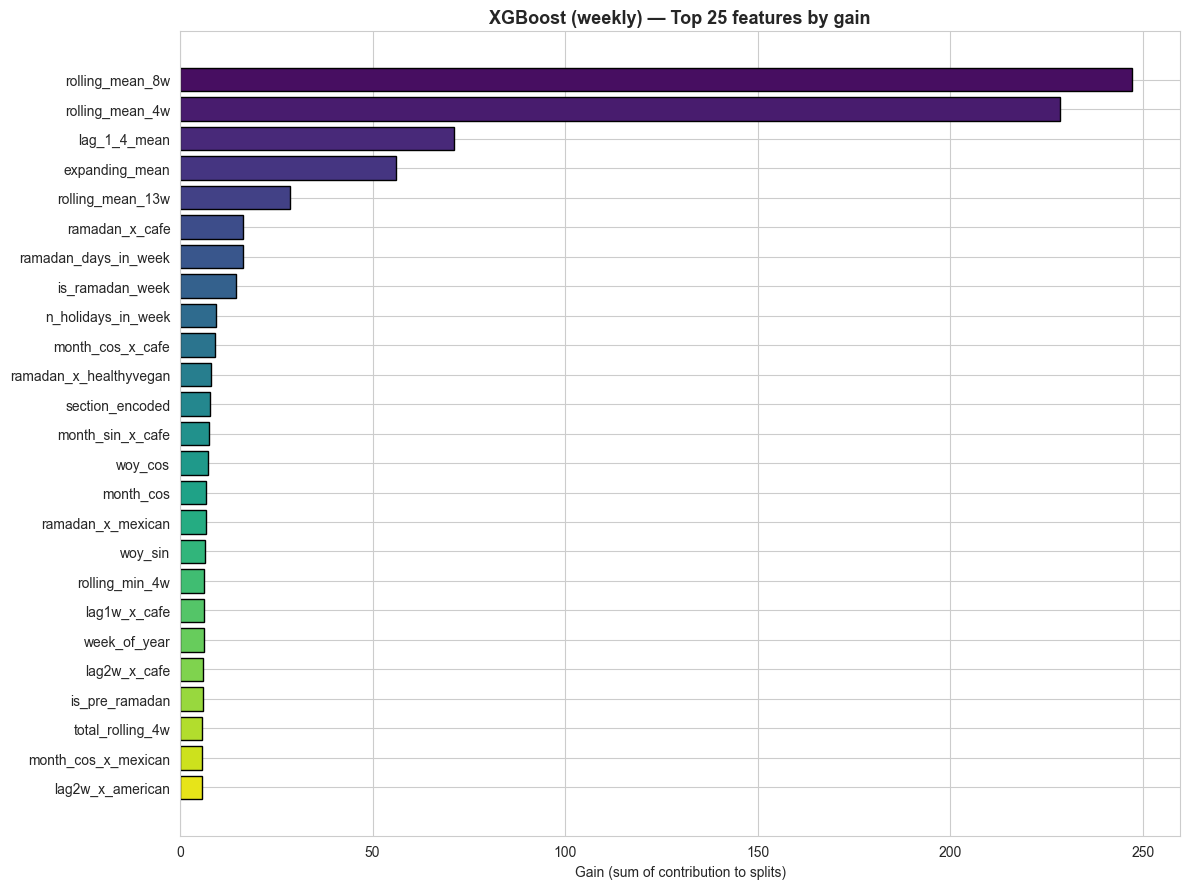


Saved: xgboost_weekly_feature_importance.csv


In [14]:
# Three importance metrics — they tell different stories
importance_gain = pd.Series(model.get_score(importance_type='gain')).sort_values(ascending=False)
importance_weight = pd.Series(model.get_score(importance_type='weight')).sort_values(ascending=False)
importance_cover = pd.Series(model.get_score(importance_type='cover')).sort_values(ascending=False)

importance_df = pd.DataFrame({
    'gain': importance_gain,
    'weight': importance_weight,
    'cover': importance_cover,
}).fillna(0).sort_values('gain', ascending=False)

# Top 30 by gain
top_30 = importance_df.head(30)

print("=" * 70)
print("TOP 30 FEATURES BY GAIN (information value added by each split)")
print("=" * 70)
print(top_30[['gain', 'weight']].round(2).to_string())

# Visualize top 25 by gain
fig, ax = plt.subplots(figsize=(12, 9))
top_25_gain = importance_df.head(25)
colors = sns.color_palette('viridis', len(top_25_gain))
ax.barh(range(len(top_25_gain)), top_25_gain['gain'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_25_gain)))
ax.set_yticklabels(top_25_gain.index, fontsize=10)
ax.set_xlabel('Gain (sum of contribution to splits)')
ax.set_title('XGBoost (weekly) — Top 25 features by gain')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('xgboost_weekly_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save full importance for SHAP analysis later
importance_df.to_csv(os.path.join(DATASETS_DIR, 'xgboost_weekly_feature_importance.csv'))
print(f"\nSaved: xgboost_weekly_feature_importance.csv")


## 14. Sample predictions across volume tiers


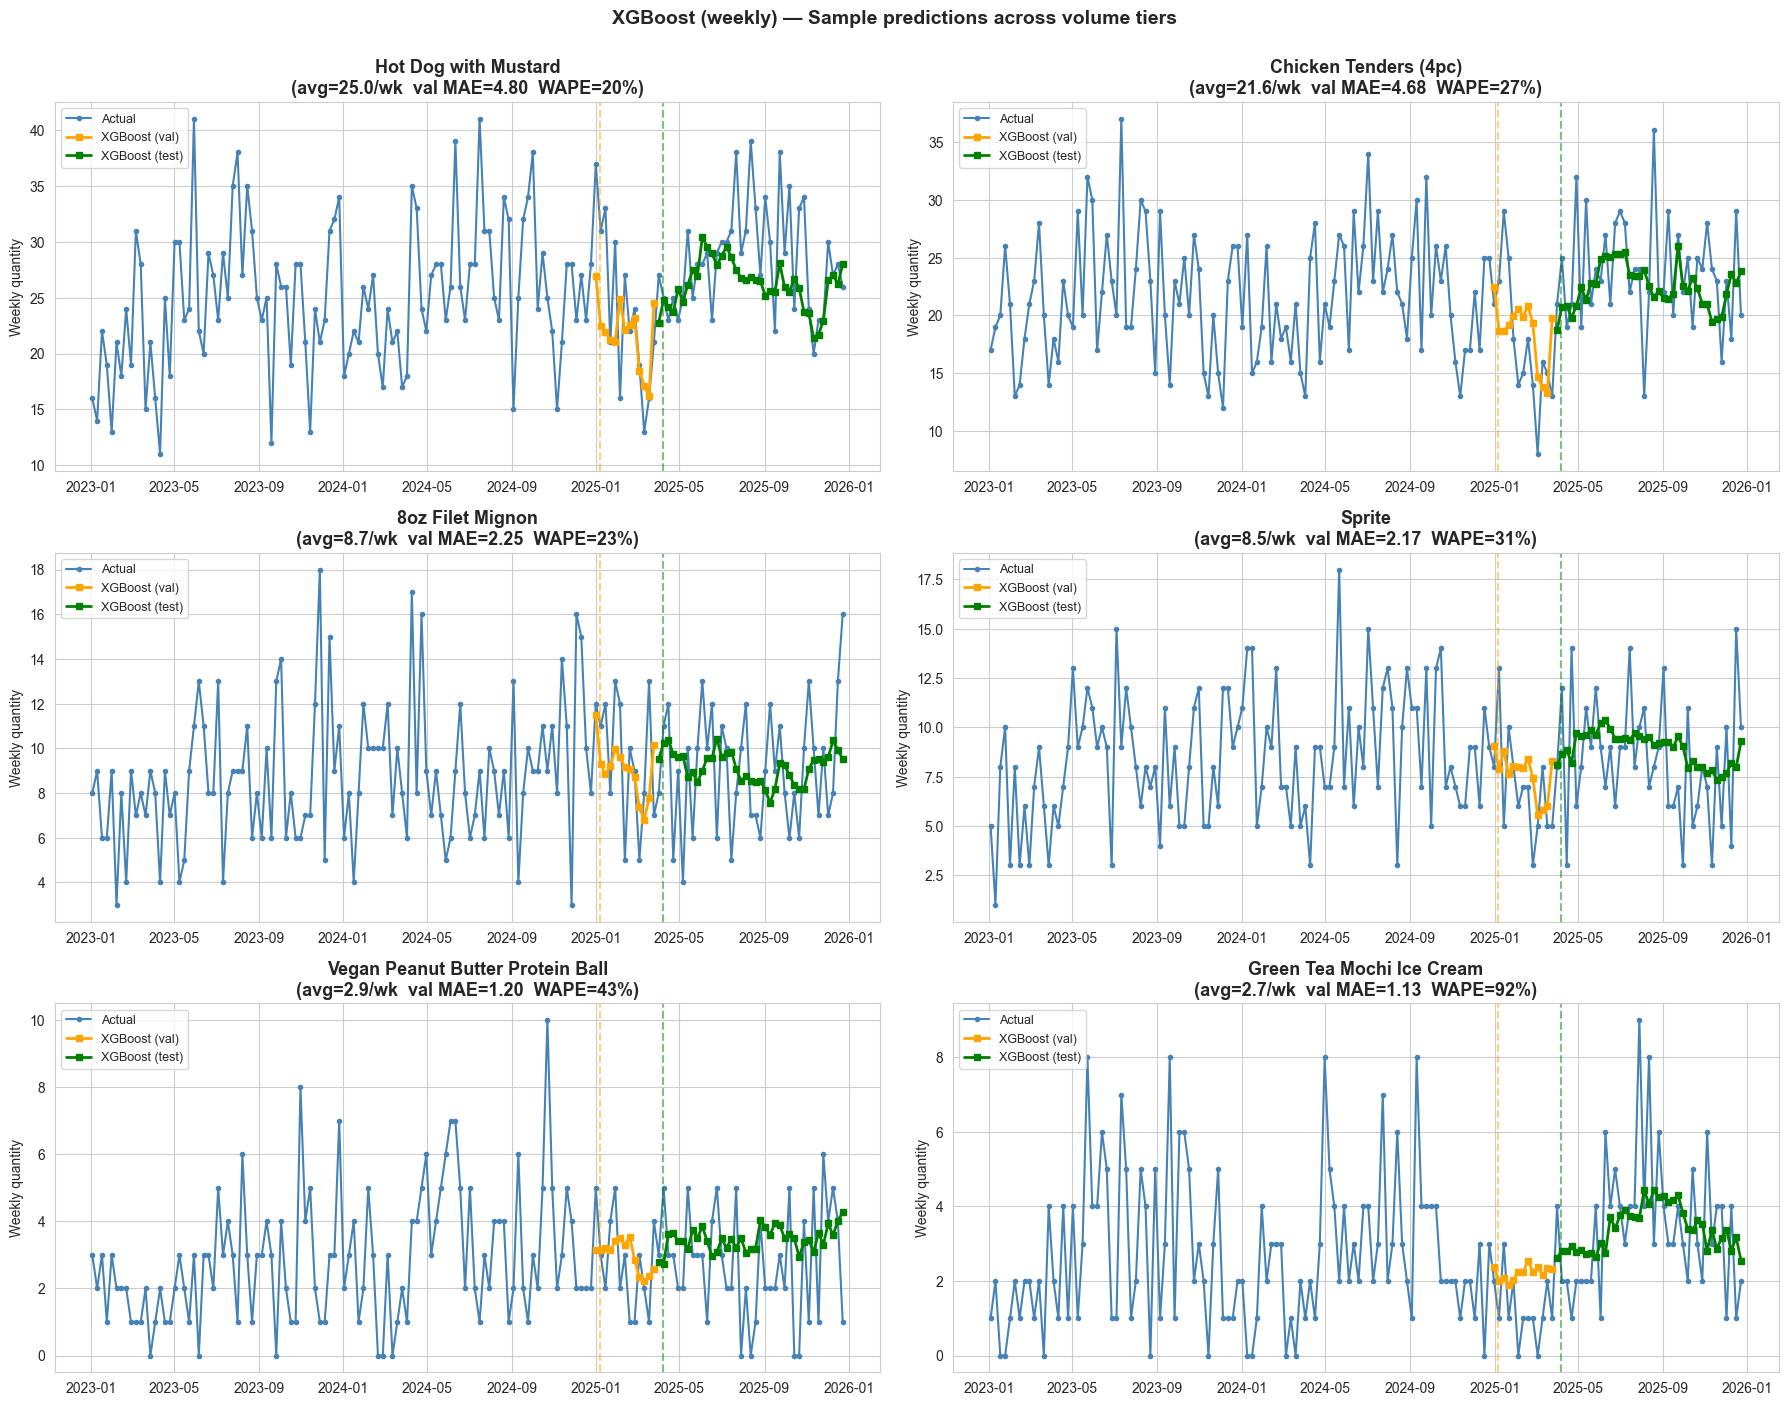

In [15]:
sample_items = []
sample_items += list(item_volume.head(2).index)
mid_idx = len(item_volume) // 2
sample_items += list(item_volume.iloc[mid_idx-1:mid_idx+1].index)
sample_items += list(item_volume.tail(2).index)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, item in zip(axes, sample_items):
    item_full = df_orig[df_orig['item_name'] == item].set_index('week_start')['quantity']
    ax.plot(item_full.index, item_full.values, color='steelblue', linewidth=1.5,
            marker='o', markersize=3, label='Actual')

    item_pred = predictions_df[predictions_df['item_name'] == item].copy()
    item_pred['ds'] = pd.to_datetime(item_pred['ds'])

    for split, color in [('val', 'orange'), ('test', 'green')]:
        sp = item_pred[item_pred['split'] == split].sort_values('ds')
        ax.plot(sp['ds'], sp['predicted'], color=color, linewidth=2,
                marker='s', markersize=4, label=f'XGBoost ({split})')

    ax.axvline(pd.Timestamp('2025-01-06'), color='orange', linestyle='--', alpha=0.5)
    ax.axvline(pd.Timestamp('2025-04-07'), color='green', linestyle='--', alpha=0.5)

    avg = item_volume[item]
    val_metrics = metrics_df[(metrics_df['item_name']==item) & (metrics_df['split']=='val')]
    if len(val_metrics) > 0:
        val_mae = val_metrics['mae'].values[0]
        val_wape = val_metrics['wape'].values[0]
        ax.set_title(f'{item}\n(avg={avg:.1f}/wk  val MAE={val_mae:.2f}  WAPE={val_wape*100:.0f}%)')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylabel('Weekly quantity')

plt.suptitle('XGBoost (weekly) — Sample predictions across volume tiers',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('xgboost_weekly_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Residual diagnostics


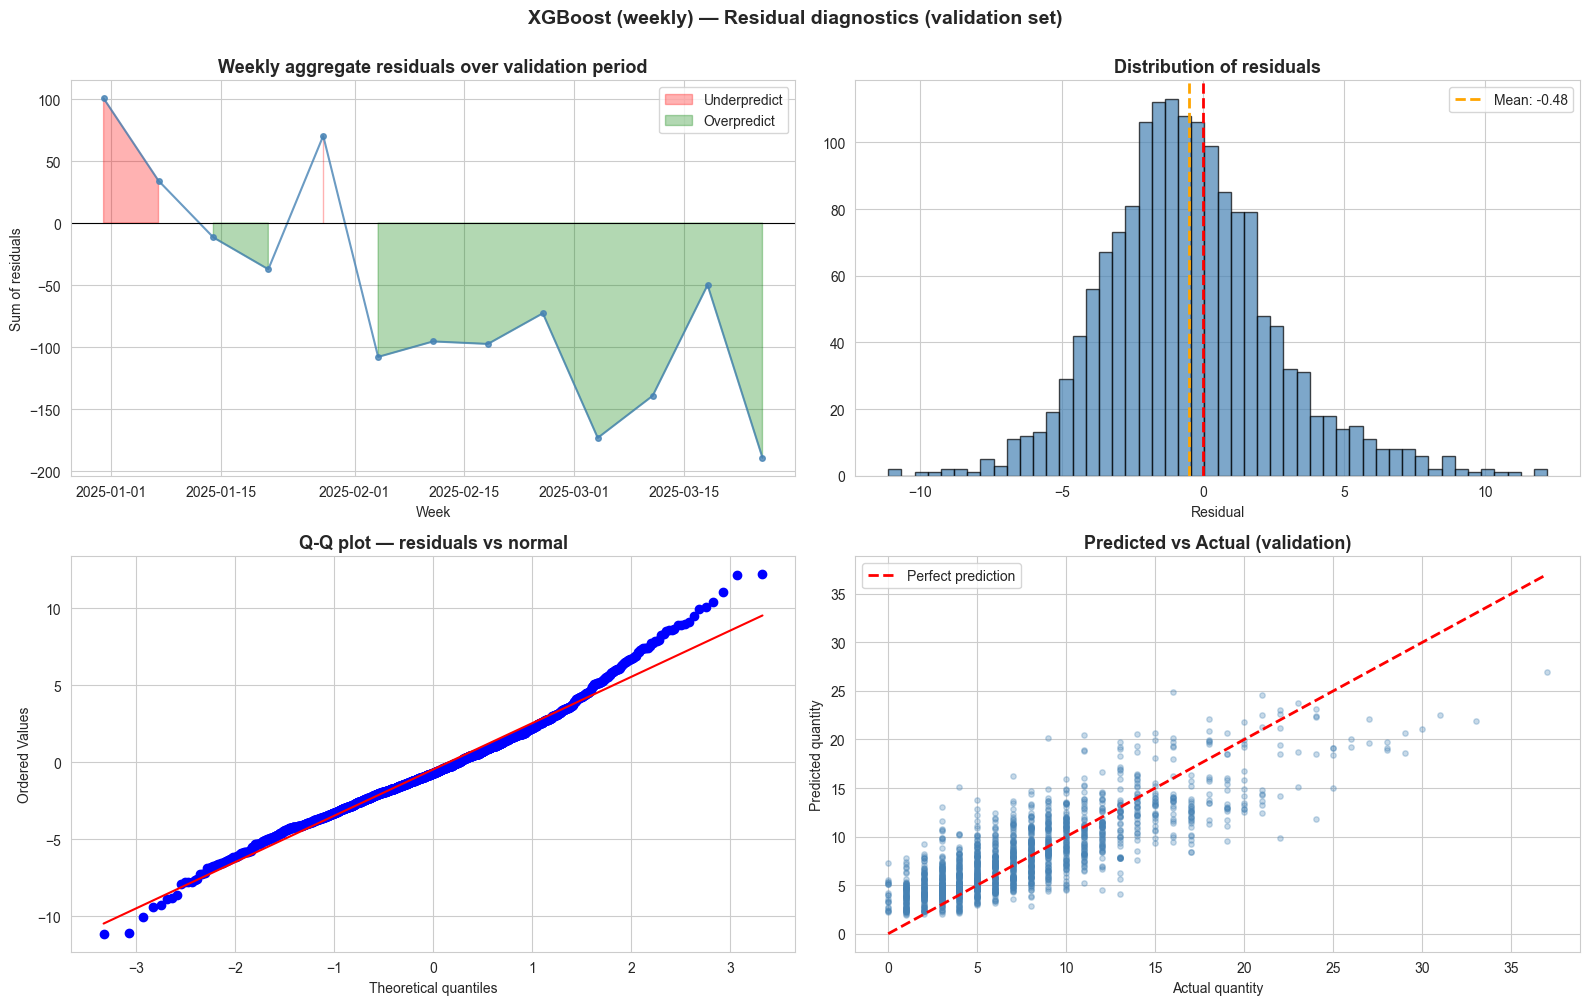


Residual statistics (validation):
  Mean:     -0.4843
  Median:   -0.7213
  Std:      3.0268
  Skewness: 0.4639
  Kurtosis: 1.1116


In [16]:
val_pred = predictions_df[predictions_df['split'] == 'val'].copy()
val_pred['residual'] = val_pred['actual'] - val_pred['predicted']
val_pred['ds'] = pd.to_datetime(val_pred['ds'])

weekly_residuals = val_pred.groupby('ds').agg(sum_residual=('residual', 'sum')).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(weekly_residuals['ds'], weekly_residuals['sum_residual'],
        color='steelblue', linewidth=1.5, alpha=0.8, marker='o', markersize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(weekly_residuals['ds'], 0, weekly_residuals['sum_residual'],
                where=(weekly_residuals['sum_residual'] > 0), alpha=0.3, color='red', label='Underpredict')
ax.fill_between(weekly_residuals['ds'], 0, weekly_residuals['sum_residual'],
                where=(weekly_residuals['sum_residual'] <= 0), alpha=0.3, color='green', label='Overpredict')
ax.set_title('Weekly aggregate residuals over validation period')
ax.set_xlabel('Week')
ax.set_ylabel('Sum of residuals')
ax.legend()

# 2. Histogram
ax = axes[0, 1]
sample_res = val_pred['residual'].sample(min(5000, len(val_pred)), random_state=42)
ax.hist(sample_res, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(sample_res.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {sample_res.mean():.2f}')
ax.set_title('Distribution of residuals')
ax.set_xlabel('Residual')
ax.legend()

# 3. Q-Q plot
ax = axes[1, 0]
stats.probplot(sample_res, dist='norm', plot=ax)
ax.set_title('Q-Q plot — residuals vs normal')

# 4. Predicted vs actual
ax = axes[1, 1]
sample_ap = val_pred.sample(min(3000, len(val_pred)), random_state=42)
ax.scatter(sample_ap['actual'], sample_ap['predicted'], alpha=0.3, s=15, color='steelblue')
max_val = max(sample_ap['actual'].max(), sample_ap['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual quantity')
ax.set_ylabel('Predicted quantity')
ax.set_title('Predicted vs Actual (validation)')
ax.legend()

plt.suptitle('XGBoost (weekly) — Residual diagnostics (validation set)',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('xgboost_weekly_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResidual statistics (validation):")
print(f"  Mean:     {val_pred['residual'].mean():.4f}")
print(f"  Median:   {val_pred['residual'].median():.4f}")
print(f"  Std:      {val_pred['residual'].std():.4f}")
print(f"  Skewness: {stats.skew(val_pred['residual']):.4f}")
print(f"  Kurtosis: {stats.kurtosis(val_pred['residual']):.4f}")


## 16. Error breakdown by week-of-year and month


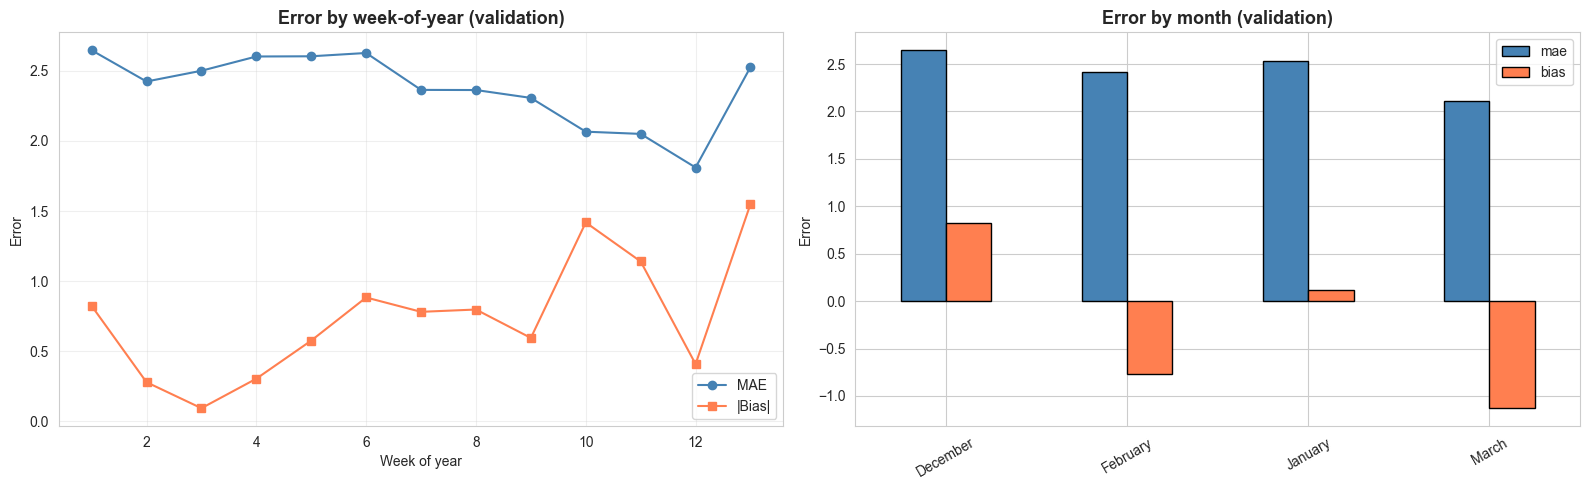

Week-of-year (top 10 weeks by MAE):
                mae   bias
week_of_year              
1             2.646  0.824
6             2.626 -0.884
5             2.603  0.576
4             2.601 -0.305
13            2.526 -1.550
3             2.500 -0.095
2             2.423  0.280
7             2.363 -0.782
8             2.362 -0.798
9             2.306 -0.596

Month:
            mae   bias
month                 
December  2.646  0.824
February  2.415 -0.765
January   2.532  0.114
March     2.113 -1.129


In [17]:
val_pred['week_of_year'] = val_pred['ds'].dt.isocalendar().week
val_pred['month'] = val_pred['ds'].dt.month_name()
val_pred['abs_error'] = np.abs(val_pred['residual'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Week-of-year MAE
ax = axes[0]
woy_err = val_pred.groupby('week_of_year').agg(mae=('abs_error','mean'), bias=('residual','mean'))
ax.plot(woy_err.index, woy_err['mae'], marker='o', color='steelblue', label='MAE')
ax.plot(woy_err.index, woy_err['bias'].abs(), marker='s', color='coral', label='|Bias|')
ax.set_title('Error by week-of-year (validation)')
ax.set_xlabel('Week of year')
ax.set_ylabel('Error')
ax.legend()
ax.grid(alpha=0.3)

# Month
ax = axes[1]
month_err = val_pred.groupby('month').agg(mae=('abs_error','mean'), bias=('residual','mean'))
month_err.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Error by month (validation)')
ax.set_ylabel('Error')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend()

plt.tight_layout()
plt.savefig('xgboost_weekly_error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("Week-of-year (top 10 weeks by MAE):")
print(woy_err.sort_values('mae', ascending=False).head(10).round(3).to_string())
print("\nMonth:")
print(month_err.round(3).to_string())


## 17. Per-item WAPE distribution and outliers


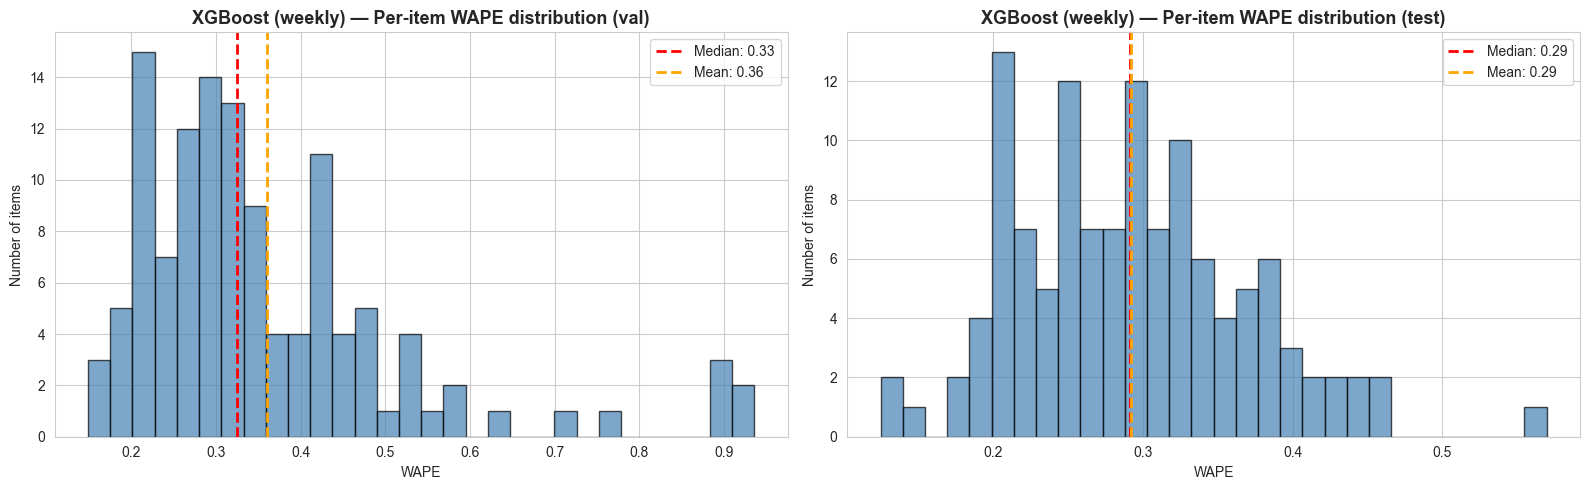

BEST 10 items (lowest WAPE on val):
                        item_name    mae   wape      r2
               Philly Cheesesteak 2.1896 0.1490  0.4196
                      Dragon Roll 1.6493 0.1600 -0.6378
               Fettuccine Alfredo 2.1217 0.1622  0.4779
Breakfast Sandwich (Egg & Cheese) 2.0468 0.1786  0.6872
                 Margherita Pizza 1.7898 0.1861  0.2137
                  Spicy Tuna Roll 2.0989 0.1921 -0.1253
                 Almond Croissant 1.5447 0.2008  0.6708
             Hot Dog with Mustard 4.8042 0.2015  0.2027
                        Black Tea 2.1965 0.2025  0.6294
                  Chicken Burrito 2.6441 0.2058 -0.2378

WORST 10 items (highest WAPE on val):
                      item_name    mae   wape      r2
                  Caprese Salad 2.2310 0.9356 -0.6360
      Green Tea Mochi Ice Cream 1.1304 0.9184 -1.6628
                   Lemon Gelato 1.5165 0.8961 -0.3391
              Vanilla Milkshake 2.3434 0.8960 -0.3650
                  Sapporo Draft 2.4689 

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split in zip(axes, ['val', 'test']):
    split_metrics = metrics_df[metrics_df['split'] == split]
    wape_clipped = split_metrics['wape'].clip(upper=3)

    ax.hist(wape_clipped, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(wape_clipped.median(), color='red', linestyle='--', linewidth=2,
               label=f'Median: {wape_clipped.median():.2f}')
    ax.axvline(wape_clipped.mean(), color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {wape_clipped.mean():.2f}')
    ax.set_title(f'XGBoost (weekly) — Per-item WAPE distribution ({split})')
    ax.set_xlabel('WAPE')
    ax.set_ylabel('Number of items')
    ax.legend()

plt.tight_layout()
plt.savefig('xgboost_weekly_wape_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("BEST 10 items (lowest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nsmallest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

print("\n" + "=" * 70)
print("WORST 10 items (highest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nlargest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))


## 18. Save model and artifacts for FastAPI deployment


In [19]:
model_path = os.path.join(MODELS_DIR, 'model.json')
model.save_model(model_path)

manifest = {
    'model_type': 'xgboost_weekly_global',
    'granularity': 'weekly',
    'n_items': len(items),
    'n_features': len(feature_cols),
    'feature_names': feature_cols,
    'target': target_col,
    'best_iteration': int(model.best_iteration),
    'best_score': float(model.best_score),
    'training_time_seconds': training_time,
    'encoding_maps': encoding_maps,
    'sections': sorted(df_orig['section'].unique().tolist()),
    'categories': sorted(df_orig['category'].unique().tolist()),
    'items': sorted(items),
    'split_dates': {
        'train_end': '2024-12-30',
        'val_end': '2025-03-31',
    },
}

with open(os.path.join(MODELS_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

print("=" * 60)
print("FASTAPI DEPLOYMENT ARTIFACTS")
print("=" * 60)
print(f"\n🚀 Model: {model_path}")
print(f"   Size: {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"\n📋 Manifest: {os.path.join(MODELS_DIR, 'manifest.json')}")
print(f"   Contains: feature order, encodings, metadata")
print(f"\nDeployment is much simpler than Prophet/SARIMA:")
print(f"  - 1 model file vs 122 per-item models")
print(f"  - Single inference call serves any item")
print(f"  - <10ms prediction latency")


FASTAPI DEPLOYMENT ARTIFACTS

🚀 Model: ../../models/xgboost\model.json
   Size: 1604.9 KB

📋 Manifest: ../../models/xgboost\manifest.json
   Contains: feature order, encodings, metadata

Deployment is much simpler than Prophet/SARIMA:
  - 1 model file vs 122 per-item models
  - Single inference call serves any item
  - <10ms prediction latency


## 19. FastAPI usage example

```python
import xgboost as xgb
import pandas as pd
import numpy as np
import json

# Load once at startup
model = xgb.Booster()
model.load_model('models/xgboost_weekly/model.json')
with open('models/xgboost_weekly/manifest.json') as f:
    manifest = json.load(f)

def predict_weekly_demand(features_dict: dict) -> float:
    """
    features_dict: {feature_name: value} for one (item, week) prediction
    Returns predicted quantity for that week.
    """
    x = np.array([features_dict[c] for c in manifest['feature_names']]).reshape(1, -1)
    dmat = xgb.DMatrix(x, feature_names=manifest['feature_names'])
    pred = model.predict(dmat)[0]
    return max(0, float(pred))  # demand can't be negative
```


## 20. Save predictions, metrics, and summary


In [20]:
output_cols = ['ds', 'item_name', 'actual', 'predicted', 'split']
predictions_df[output_cols].to_csv(os.path.join(DATASETS_DIR, 'xgboost_weekly_predictions.csv'), index=False)

metrics_df.to_csv(os.path.join(DATASETS_DIR, 'xgboost_weekly_metrics.csv'), index=False)

summary = {
    'model': 'xgboost_weekly',
    'model_type': 'global (one model for all 122 items)',
    'granularity': 'weekly',
    'n_items': len(items),
    'n_features': len(feature_cols),
    'training_time_seconds': training_time,
    'best_iteration': int(model.best_iteration),
    'overall_metrics': {},
    'per_section_metrics': {},
    'per_volume_tier_metrics': {},
    'baseline_comparison': {},
    'top_features': importance_df.head(20).to_dict('index'),
}

for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    summary['overall_metrics'][split] = {
        k: float(v) for k, v in compute_metrics(sp['actual'].values, sp['predicted'].values).items()
    }

for split in ['val', 'test']:
    summary['per_section_metrics'][split] = {}
    for sec in section_results['section'].unique():
        row = section_results[(section_results['section']==sec) & (section_results['split']==split)]
        if len(row) > 0:
            summary['per_section_metrics'][split][sec] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for split in ['val', 'test']:
    summary['per_volume_tier_metrics'][split] = {}
    for tier in tier_order:
        row = tier_results[(tier_results['volume_tier']==tier) & (tier_results['split']==split)]
        if len(row) > 0:
            summary['per_volume_tier_metrics'][split][tier] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for _, row in comparison_df.iterrows():
    key = f"{row['Model']}_{row['Split']}"
    summary['baseline_comparison'][key] = {
        'mae': float(row['MAE']),
        'wape': float(row['WAPE']),
        'r2': float(row['R²']),
    }

with open(os.path.join(DATASETS_DIR, 'xgboost_weekly_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 60)
print("ALL ARTIFACTS SAVED")
print("=" * 60)
print(f"\n📊 For comparison notebook (05c):")
print(f"  {DATASETS_DIR}/xgboost_weekly_predictions.csv")
print(f"  {DATASETS_DIR}/xgboost_weekly_metrics.csv")
print(f"  {DATASETS_DIR}/xgboost_weekly_summary.json")
print(f"  {DATASETS_DIR}/xgboost_weekly_feature_importance.csv")
print(f"\n🚀 For FastAPI:")
print(f"  {MODELS_DIR}/model.json")
print(f"  {MODELS_DIR}/manifest.json")


ALL ARTIFACTS SAVED

📊 For comparison notebook (05c):
  ../../datasets/xgboost_weekly_predictions.csv
  ../../datasets/xgboost_weekly_metrics.csv
  ../../datasets/xgboost_weekly_summary.json
  ../../datasets/xgboost_weekly_feature_importance.csv

🚀 For FastAPI:
  ../../models/xgboost/model.json
  ../../models/xgboost/manifest.json


In [21]:
print(f"\n{'='*60}")
print("XGBOOST WEEKLY GLOBAL MODEL — COMPLETE")
print(f"{'='*60}")
print(f"\nKey deliverables:")
print(f"  ✓ 1 global model trained on {len(items)} items × {len(feature_cols)} features")
print(f"  ✓ Predictions for val + test splits")
print(f"  ✓ Live training loss curves (boosting iterations)")
print(f"  ✓ Feature importance — gain, weight, cover")
print(f"  ✓ Per-section + per-tier breakdowns")
print(f"  ✓ Sample predictions across volume tiers")
print(f"  ✓ Residual diagnostics + Q-Q + scatter")
print(f"  ✓ Error breakdown by week-of-year + month")
print(f"  ✓ FastAPI deployment artifacts")
print(f"\nVal WAPE: {summary['overall_metrics']['val']['wape']:.4f}")
print(f"Val R²:   {summary['overall_metrics']['val']['r2']:+.4f}")
print(f"\nNext: 05b_lightgbm_weekly.ipynb")



XGBOOST WEEKLY GLOBAL MODEL — COMPLETE

Key deliverables:
  ✓ 1 global model trained on 122 items × 84 features
  ✓ Predictions for val + test splits
  ✓ Live training loss curves (boosting iterations)
  ✓ Feature importance — gain, weight, cover
  ✓ Per-section + per-tier breakdowns
  ✓ Sample predictions across volume tiers
  ✓ Residual diagnostics + Q-Q + scatter
  ✓ Error breakdown by week-of-year + month
  ✓ FastAPI deployment artifacts

Val WAPE: 0.3073
Val R²:   +0.6579

Next: 05b_lightgbm_weekly.ipynb
